# 02 - EDA estadístico

**TFM: Predicción de emisiones de CO₂ de buques**

Parte de `data/processed/mrv_consolidado.parquet` (notebook 01), filtrado a
`report_coverage == 'Full'` (ver notebook 01, Sección 6: los informes `Partial` se solapan con los
`Full` y no deben mezclarse como observaciones independientes).

Este notebook:
1. Selecciona el subconjunto de variables núcleo relevantes para explicar las emisiones (evitando
   las columnas "por distancia" / "por trabajo de transporte", que son ratios derivados
   matemáticamente del propio CO₂ o combustible — usarlas como predictoras sería casi circular).
2. Extrae del campo de texto libre `technical_efficiency` el método (EEDI/EIV/EEXI) y el valor
   numérico, como variables nuevas.
3. Trata los atípicos combinando cota física (cuando existe) + criterio estadístico
   (`atipicosAmissing`), y muestra por qué el orden
   importa (efecto de enmascaramiento).
4. Analiza el patrón de missings, construye `prop_missings` (proporción de missing por fila) y los imputa (`ImputacionCuant`/`ImputacionCuali`).
5. Estudia la relación de cada variable con el target (`total_co2_emissions_m_tonnes`): correlación
   para las numéricas, V de Cramer (con su test chi-cuadrado explícito) para las categóricas, un
   ANOVA para `ship_type`, y la mejor transformación disponible.
6. Guarda un dataset "listo para modelización" en `data/processed/mrv_modelizacion.parquet`.

**Dos decisiones clave** (secciones 6b y 8): el criterio estadístico de atípicos no se aplica al
CO₂ ni al combustible, y la variable objetivo no se imputa. Aplicarlo descartaría ~3% de las filas,
que concentran cerca del 19% de todas las emisiones — los mayores emisores de la flota —, tratándolos
como errores de medida cuando el chequeo físico demuestra que son datos correctos.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway

sys.path.append(str(Path.cwd().parent / "src"))
from eda_utils import (
    analizar_variables_categoricas, cuentaDistintos, atipicosAmissing, patron_perdidos,
    ImputacionCuant, ImputacionCuali, Vcramer, graficoVcramer, mejorTransfCorr,
)

pd.set_option("display.max_columns", 50)
np.random.seed(42)  # reproducibilidad de las imputaciones aleatorias

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
REPORTS_DIR = Path.cwd().parent / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

datos_todos = pd.read_parquet(PROCESSED_DIR / "mrv_consolidado.parquet")
datos = datos_todos[datos_todos.report_coverage == "Full"].copy().reset_index(drop=True)
print(f"Informes 'Full': {len(datos):,} de {len(datos_todos):,} filas totales (excluye 'Partial')".replace(",", "."))

Informes 'Full': 106.701 de 109.240 filas totales (excluye 'Partial')


## 1. Selección de variables núcleo

El dataset consolidado tiene 134 columnas, pero la mayoría son ratios "por distancia" o "por
trabajo de transporte" (p.ej. `co2_emissions_per_distance_kg_co2_n_mile`) que se calculan
dividiendo el propio CO₂ o combustible entre la distancia o la carga — son el resultado, no la
causa, y meterlas como variables explicativas del CO₂ total sería casi tautológico (correlación
altísima por construcción, no por relación causal real). Se conservan las variables "totales"
que sí son insumos independientes, más la identificación del buque y del año.

In [2]:
id_vars = ["reporting_year", "ship_imo_number", "ship_name", "company_name"]
nucleo_num = [
    "total_co2_emissions_m_tonnes",       # variable objetivo
    "total_fuel_consumption_m_tonnes",
    "time_spent_at_sea_hours",
]
nucleo_cat = ["ship_type", "ice_class", "technical_efficiency"]

datos = datos[id_vars + nucleo_num + nucleo_cat].copy()
datos.head(3)

,reporting_year,ship_imo_number,ship_name,company_name,total_co2_emissions_m_tonnes,total_fuel_consumption_m_tonnes,time_spent_at_sea_hours,ship_type,ice_class,technical_efficiency
0,2018,5383304,ASTORIA,NaN,20080.2509,6307.75,4170.20,Passenger ship,NaN,Not Applicable
1,2018,6417097,MARCO POLO,NaN,25689.0258,8125.56,4360.57,Passenger ship,IC,Not Applicable
2,2018,6511128,RED STAR 1,NaN,6941.3412,2205.37,2712.00,Ro-pax ship,NaN,EIV (45.57 gCO₂/t·nm)


## 2. Feature engineering ligero: método y valor del indicador de eficiencia técnica

`technical_efficiency` es texto libre del tipo `'EIV (45.57 gCO₂/t·nm)'` o `'Not Applicable'`.
Se separa el método (EEDI/EIV/EEXI/Not Applicable) del valor numérico — el método por sí solo ya
es informativo (indica la antigüedad/normativa aplicable al buque: EIV es el índice para buques
anteriores a 2013, EEDI para buques nuevos, EEXI es el de la revisión de 2023).

In [3]:
import re

def _parse_technical_efficiency(s):
    if pd.isna(s):
        return pd.Series({"te_metodo": np.nan, "te_valor": np.nan})
    s = str(s)
    m = re.match(r"([A-Za-z][A-Za-z\s]*?)\s*(?:\(|$)", s)
    metodo = m.group(1).strip() if m else np.nan
    m2 = re.search(r"([\d]+\.?[\d]*)\s*gCO", s)
    valor = float(m2.group(1)) if m2 else np.nan
    return pd.Series({"te_metodo": metodo, "te_valor": valor})

datos[["te_metodo", "te_valor"]] = datos["technical_efficiency"].apply(_parse_technical_efficiency)
datos["te_metodo"].value_counts(dropna=False)

te_metodo
EIV               48580
EEXI              26650
EEDI              25154
Not Applicable     4539
NaN                1778
Name: count, dtype: int64

## 3. Tipos de variable y nº de valores distintos

In [4]:
variables = [c for c in datos.columns if c not in ["ship_imo_number", "ship_name", "company_name", "technical_efficiency"]]
numericas = datos[variables].select_dtypes(include=["int", "int32", "int64", "float", "float32", "float64"]).columns.tolist()
categoricas = [v for v in variables if v not in numericas]
print(f"Numéricas: {numericas}")
print(f"Categóricas: {categoricas}")
cuentaDistintos(datos[numericas])

Numéricas: ['reporting_year', 'total_co2_emissions_m_tonnes', 'total_fuel_consumption_m_tonnes', 'time_spent_at_sea_hours', 'te_valor']
Categóricas: ['ship_type', 'ice_class', 'te_metodo']


,Columna,Distintos
0,reporting_year,8
1,total_co2_emissions_m_tonnes,100579
2,total_fuel_consumption_m_tonnes,91393
3,time_spent_at_sea_hours,74919
4,te_valor,3419


## 4. Descriptivos numéricos (antes de tratar atípicos)

In [5]:
nucleo_num_ext = nucleo_num + ["te_valor"]
descriptivos = datos[nucleo_num_ext].describe().T
for c in nucleo_num_ext:
    descriptivos.loc[c, "Asimetria"] = datos[c].skew()
    descriptivos.loc[c, "Curtosis"] = datos[c].kurtosis()
descriptivos

,count,mean,std,min,25%,50%,75%,max,Asimetria,Curtosis
total_co2_emissions_m_tonnes,106701.0,10428.648649,1.378313e+04,0.0,2780.70536,5768.74601,11841.66,3.154785e+05,3.086564,13.973860
total_fuel_consumption_m_tonnes,106701.0,3354.489668,4.475105e+03,0.0,885.05000,1839.18000,3791.90,9.846520e+04,3.101058,13.762450
time_spent_at_sea_hours,106701.0,7912.671304,1.847228e+06,0.0,902.30000,1834.40000,3388.98,6.034010e+08,326.650665,106700.771095
te_valor,100778.0,16.432322,9.555612e+02,0.0,4.19000,6.64000,13.30,2.083900e+05,207.642383,44946.418338


Asimetrías muy altas y máximos muy por encima del percentil 75 en `total_co2_emissions_m_tonnes`
y `total_fuel_consumption_m_tonnes` — esperable en flotas reales (unos pocos buques enormes junto
a muchos pequeños), pero confirma que hace falta revisar atípicos antes de modelizar.

## 5. Variables categóricas: frecuencias

In [6]:
resumen_cat = analizar_variables_categoricas(datos[["ship_type", "ice_class", "te_metodo"]])
for var, resumen in resumen_cat.items():
    print(f"--- {var} ---")
    print(resumen.head(8))
    print()

--- ship_type ---
                        n         %
ship_type                          
Bulk carrier        32186  0.301647
Container ship      15747  0.147581
Oil tanker          15673  0.146887
General cargo ship  11609  0.108799
Chemical tanker     11390  0.106747
Vehicle carrier      3743  0.035079
Ro-pax ship          3231  0.030281
Gas carrier          2859  0.026795

--- ice_class ---
              n         %
ice_class                
IA         9333  0.526366
IC         4861  0.274153
IB         1914  0.107947
IA Super    996  0.056173
PC1         203  0.011449
PC3         139  0.007839
PC7         111  0.006260
PC6          69  0.003891

--- te_metodo ---
                    n         %
te_metodo                      
EIV             48580  0.463006
EEXI            26650  0.253996
EEDI            25154  0.239738
Not Applicable   4539  0.043260



## 6. Atípicos — por qué el orden importa (efecto de enmascaramiento)

En el notebook 01 aparece un valor de `time_spent_at_sea_hours` físicamente imposible (603
millones de horas). Antes de aplicar el criterio estadístico genérico (`atipicosAmissing`), se
comprueba qué pasa si se aplica directamente sin quitar antes ese valor extremo.

In [7]:
# Intento ingenuo: atipicosAmissing directamente, sin cota física antes
_, n_ingenuo = atipicosAmissing(datos["time_spent_at_sea_hours"])
horas_max_fisico = 366 * 24
n_imposibles_reales = (datos["time_spent_at_sea_hours"] > horas_max_fisico).sum()
print(f"Atípicos detectados por el criterio estadístico (sin cota física antes): {n_ingenuo}")
print(f"Valores físicamente imposibles que sabemos que existen (>{horas_max_fisico}h/año): {n_imposibles_reales}")

Atípicos detectados por el criterio estadístico (sin cota física antes): 6
Valores físicamente imposibles que sabemos que existen (>8784h/año): 19


El criterio estadístico por sí solo detecta muchos menos casos de los que se sabe que son
imposibles: el propio valor de 603 millones de horas dispara tanto la desviación típica / MAD que
"esconde" al resto de valores igual de imposibles pero menos extremos (efecto de enmascaramiento,
un problema conocido de los métodos de detección de atípicos basados en escala). La solución es
aplicar primero la cota física, que no depende de la escala de los demás datos, y dejar el
criterio estadístico para lo que no tiene un límite físico tan claro.

In [8]:
# 1) Cota física primero: horas en mar por encima de las que tiene el año
datos.loc[datos["time_spent_at_sea_hours"] > horas_max_fisico, "time_spent_at_sea_hours"] = np.nan

# 2) Cota física para CO2/combustible: el ratio debe rondar el factor de emisión del fuel marino
#    (~3,11-3,21 t CO2 / t combustible; ver notebook 01, sección 7b). Fuera de [2,5, 3,3] no
#    se sabe cuál de las dos variables está mal, así que se marcan ambas como missing.
ratio_co2_fuel = datos["total_co2_emissions_m_tonnes"] / datos["total_fuel_consumption_m_tonnes"]
ratio_fuera_rango = (datos["total_fuel_consumption_m_tonnes"] > 0) & ((ratio_co2_fuel < 2.5) | (ratio_co2_fuel > 3.3))
datos.loc[ratio_fuera_rango, ["total_co2_emissions_m_tonnes", "total_fuel_consumption_m_tonnes"]] = np.nan
print(f"Filas marcadas como missing por cota física: horas={int((datos['time_spent_at_sea_hours'].isna()).sum())}, "
      f"ratio CO2/fuel={int(ratio_fuera_rango.sum())}")

# 3) Criterio estadístico (atipicosAmissing) SOLO sobre las variables donde un valor extremo es
#    sospechoso de ser un error de medida y no existe una cota física que ya lo acote.
#
#    Se dejan fuera a propósito el CO2 y el combustible (ver la comprobación de la celda
#    siguiente y la justificación en el texto): en una distribución de emisiones la cola derecha
#    es señal, no error, y los errores reales de estas dos variables ya los caza la cota física
#    del paso 2, que es un criterio de dominio y no de escala.
VARS_CRITERIO_ESTADISTICO = ["time_spent_at_sea_hours"]
VARS_SIN_CRITERIO_ESTADISTICO = ["total_co2_emissions_m_tonnes", "total_fuel_consumption_m_tonnes"]

n_atipicos_estadisticos = {}
for c in VARS_CRITERIO_ESTADISTICO:
    serie, n = atipicosAmissing(datos[c])
    n_atipicos_estadisticos[c] = n
    datos[c] = serie
n_atipicos_estadisticos

Filas marcadas como missing por cota física: horas=19, ratio CO2/fuel=180


{'time_spent_at_sea_hours': 0}

In [9]:
# Comprobación de la decisión: ¿qué habría descartado el criterio estadístico sobre CO2 y
# combustible, y era realmente erróneo? (no modifica `datos`, solo mide)
resumen_descartes = []
for c in VARS_SIN_CRITERIO_ESTADISTICO:
    _serie_hipotetica, n_hip = atipicosAmissing(datos[c])
    marcados = _serie_hipotetica.isna() & datos[c].notna()
    resumen_descartes.append({
        "variable": c,
        "n_marcados": int(n_hip),
        "%_filas": round(100 * n_hip / len(datos), 2),
        "valor_min_marcado": round(float(datos.loc[marcados, c].min()), 1) if marcados.any() else np.nan,
    })
print(pd.DataFrame(resumen_descartes).to_string(index=False))

# ¿Cuánto CO2 representan las filas que el criterio estadístico habría marcado?
_co2_hip, _ = atipicosAmissing(datos["total_co2_emissions_m_tonnes"])
marcados_co2 = _co2_hip.isna() & datos["total_co2_emissions_m_tonnes"].notna()
cuota = datos.loc[marcados_co2, "total_co2_emissions_m_tonnes"].sum() / datos["total_co2_emissions_m_tonnes"].sum()
print(f"\nEsas filas son el {marcados_co2.mean():.2%} del dataset pero el {cuota:.1%} de todo el CO2 emitido.")

# ¿Son errores? El chequeo físico independiente lo dice: ratio CO2/combustible dentro del
# factor de emisión del fuel marino.
ratio_marcados = (datos.loc[marcados_co2, "total_co2_emissions_m_tonnes"]
                  / datos.loc[marcados_co2, "total_fuel_consumption_m_tonnes"])
print(f"De ellas, {ratio_marcados.between(2.5, 3.3).sum()} de {int(marcados_co2.sum())} "
      f"tienen un ratio CO2/combustible físicamente correcto (mediana {ratio_marcados.median():.3f}).")
print("\nLos 5 mayores emisores que el criterio estadístico habría descartado:")
print(datos.loc[marcados_co2].nlargest(5, "total_co2_emissions_m_tonnes")
      [["ship_name", "ship_type", "total_co2_emissions_m_tonnes", "total_fuel_consumption_m_tonnes"]]
      .to_string(index=False))

                       variable  n_marcados  %_filas  valor_min_marcado
   total_co2_emissions_m_tonnes        3140     2.94            49620.8
total_fuel_consumption_m_tonnes        3241     3.04            15841.8

Esas filas son el 2.94% del dataset pero el 18.8% de todo el CO2 emitido.
De ellas, 3140 de 3140 tienen un ratio CO2/combustible físicamente correcto (mediana 3.120).

Los 5 mayores emisores que el criterio estadístico habría descartado:


       ship_name      ship_type  total_co2_emissions_m_tonnes  total_fuel_consumption_m_tonnes
     STELLA HOPE   Bulk carrier                   315478.5124                         98465.20
NORWEGIAN SPIRIT Passenger ship                   179701.6581                         57575.36
    QUEEN MARY 2 Passenger ship                   167531.1818                         53501.90
   CRUISE EUROPA    Ro-pax ship                   158508.5838                         50662.03
  CRUISE OLYMPIA    Ro-pax ship                   156495.2176                         49964.11


### 6b. Por qué el CO₂ y el combustible quedan fuera del criterio estadístico

La comprobación de arriba es la que motiva la decisión, que es una desviación deliberada respecto
de la receta genérica de depuración:

1. **El criterio de `atipicosAmissing` es de escala, no de dominio.** Sus dos condiciones
   (distancia a la mediana en MAD, y rango intercuartílico ampliado) miden "cuán lejos está este
   valor del resto", no "cuán plausible es". En una flota real la cola derecha de las emisiones no
   es ruido: son portacontenedores, cruceros y ro-pax grandes que emiten de verdad esas cifras.
   Entre los que el criterio marcaría están el *Queen Mary 2* o el *Norwegian Spirit*, con
   consumos perfectamente coherentes con su tamaño.

2. **Hay un criterio físico que sí distingue error de tamaño, y ya está aplicado.** El CO₂ y el
   combustible están ligados por el factor de emisión del fuel marino (~3,11–3,21 t CO₂/t). La
   práctica totalidad de las filas que el criterio estadístico marcaría tienen un ratio dentro de
   ese rango: no son errores de medida, son buques grandes. Las que sí están mal ya se han puesto
   a missing en el paso 2.

3. **Sobre la variable objetivo, marcar atípicos es directamente inadmisible.** El paso siguiente
   de la receta es imputar los missings, y en el caso del CO₂ eso significa *inventarse por sorteo
   el valor que después se quiere predecir*. Si el CO₂ de una fila no es fiable, la fila se
   descarta (lo hace el notebook 03); no se fabrica.

El efecto de esta decisión no es cosmético: afecta a ~3% de las filas pero a cerca de **una quinta
parte de todas las emisiones del dataset**. Aplicando la receta sin pensar, el modelo del notebook
04 nunca vería a los buques que más contaminan — justo los que más importan en un trabajo sobre
predicción y reducción de emisiones.

## 7. Patrón de valores perdidos

In [10]:
datos[nucleo_num_ext].isna().mean().to_frame("proporcion_missing")

,proporcion_missing
total_co2_emissions_m_tonnes,0.001687
total_fuel_consumption_m_tonnes,0.001687
time_spent_at_sea_hours,0.000178
te_valor,0.055510


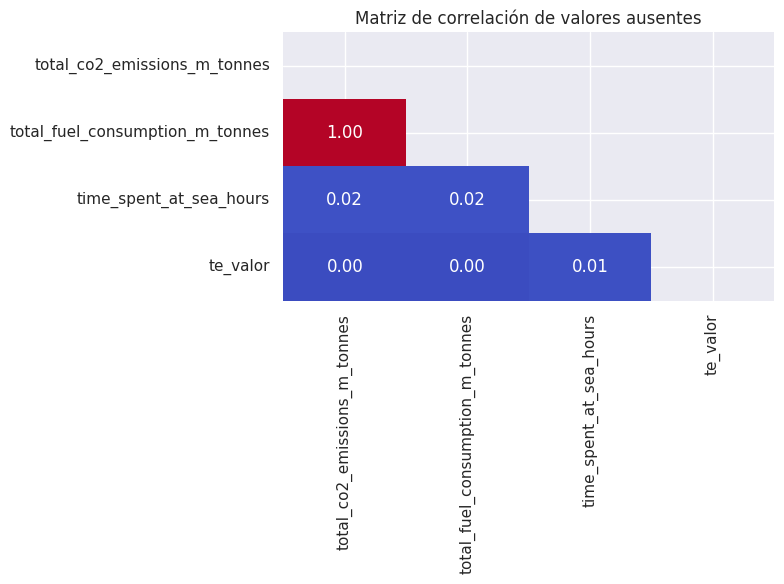

In [11]:
patron_perdidos(datos[nucleo_num_ext])
plt.savefig(REPORTS_DIR / "02_patron_missings.png", dpi=120, bbox_inches="tight")

`ice_class` tiene muchos missings, pero aquí un missing es informativo: significa que el buque no
tiene clase de hielo asignada, no que falte el dato. Se imputa como categoría explícita, no de
forma aleatoria.

In [12]:
print(f"ice_class missing: {datos['ice_class'].isna().mean():.1%}")
datos["ice_class"] = datos["ice_class"].fillna("Sin clase de hielo")

ice_class missing: 83.4%


### 7b. Variable derivada: proporción de missing por fila

Se añade una variable que resume cuántos de los valores núcleo de esa fila han quedado como missing tras el tratamiento de
atípicos — puede ser en sí misma informativa (p.ej. si los buques con más datos incompletos tienden
a ser distintos en sus emisiones). Se calcula solo sobre `nucleo_num_ext` (CO2, combustible, horas,
`te_valor`): se deja fuera `ice_class` a propósito, porque su missing es estructural (buque sin
clase de hielo asignada, ya tratado como categoría explícita en el paso anterior) y no un dato que
falte por un problema de calidad — mezclarlo aquí diluiría la señal que interesa capturar.

In [13]:
datos["prop_missings"] = datos[nucleo_num_ext].isna().mean(axis=1)
print(datos["prop_missings"].value_counts(normalize=True).sort_index())
# Pocos valores distintos: se trata como categórica
datos["prop_missings"] = datos["prop_missings"].astype(str)
nucleo_cat.append("prop_missings")

prop_missings
0.00    0.942793
0.25    0.055473
0.50    0.001612
0.75    0.000122
Name: proportion, dtype: float64


## 8. Imputación

Se imputan los missings de los **predictores** con `ImputacionCuant`/`ImputacionCuali` (sorteo
según la distribución empírica).

La **variable objetivo no se imputa**, y el combustible tampoco. Imputar el CO₂ significaría
fabricar por sorteo el valor que el notebook 04 tiene que aprender a predecir: las filas cuyo CO₂
no es fiable no se rellenan, se arrastran como missing y el notebook 03 decide qué hacer con ellas
(reconstruirlas a partir del combustible cuando es posible, descartarlas cuando no). El
combustible se deja igual porque está físicamente ligado al CO₂ por el factor de emisión —
imputarlo por sorteo, de forma independiente, rompería esa relación y volvería incoherentes las
dos variables a la vez.

In [14]:
# Predictores: sí se imputan
datos["time_spent_at_sea_hours"] = ImputacionCuant(datos["time_spent_at_sea_hours"], "aleatorio")
datos["te_metodo"] = datos["te_metodo"].fillna("Desconocido")
datos["te_valor"] = ImputacionCuant(datos["te_valor"], "aleatorio")

# Target (y combustible, ligado a él por el factor de emisión): NO se imputan, ver texto de arriba.
n_target_pendiente = int(datos["total_co2_emissions_m_tonnes"].isna().sum())
print(f"Filas que salen del EDA con el CO2 sin valor fiable (las resuelve el notebook 03): {n_target_pendiente}")

print("\nMissings tras imputación:")
datos[nucleo_num_ext + ["ice_class", "te_metodo"]].isna().sum()

Filas que salen del EDA con el CO2 sin valor fiable (las resuelve el notebook 03): 180

Missings tras imputación:


total_co2_emissions_m_tonnes       180
total_fuel_consumption_m_tonnes    180
time_spent_at_sea_hours              0
te_valor                             0
ice_class                            0
te_metodo                            0
dtype: int64

## 9. Distribuciones

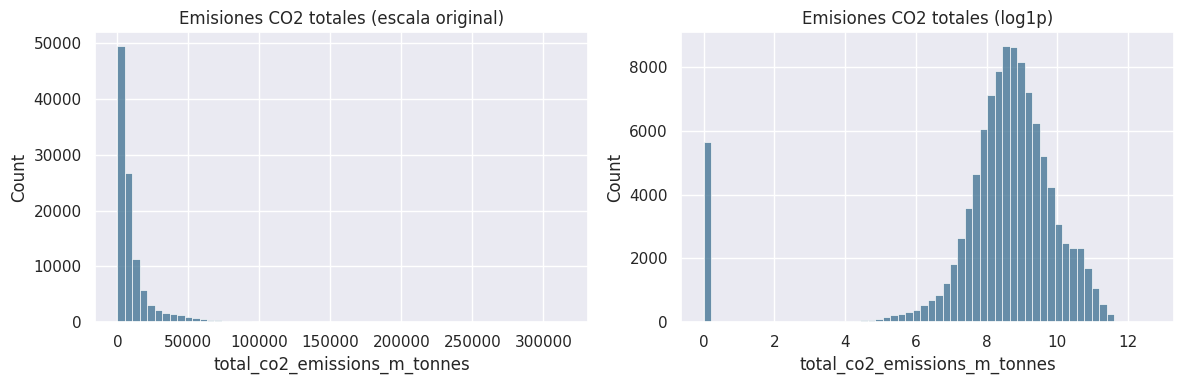

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(datos["total_co2_emissions_m_tonnes"], bins=60, ax=axes[0], color="#3B6E8F")
axes[0].set_title("Emisiones CO2 totales (escala original)")
sns.histplot(np.log1p(datos["total_co2_emissions_m_tonnes"]), bins=60, ax=axes[1], color="#3B6E8F")
axes[1].set_title("Emisiones CO2 totales (log1p)")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_distribucion_co2.png", dpi=120)
plt.show()

Fuertemente asimétrica a la derecha (muchos buques pequeños, pocos muy grandes) — típico de
variables de tamaño/actividad económica. La transformación logarítmica la aproxima bastante a una
normal, algo a tener en cuenta al elegir la métrica de error en la fase de modelización (un RMSE en
escala original estará dominado por los pocos buques gigantes).

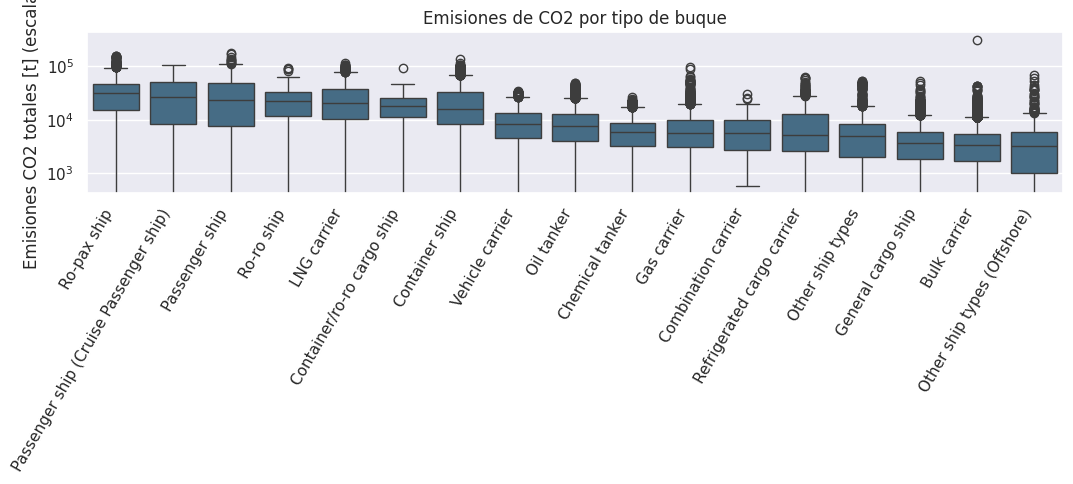

In [16]:
plt.figure(figsize=(11, 5))
orden = datos.groupby("ship_type")["total_co2_emissions_m_tonnes"].median().sort_values(ascending=False).index
sns.boxplot(data=datos, x="ship_type", y="total_co2_emissions_m_tonnes", order=orden, color="#3B6E8F")
plt.yscale("log")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Emisiones CO2 totales [t] (escala log)")
plt.xlabel("")
plt.title("Emisiones de CO2 por tipo de buque")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_co2_por_tipo_buque.png", dpi=120)
plt.show()

## 10. Evolución temporal

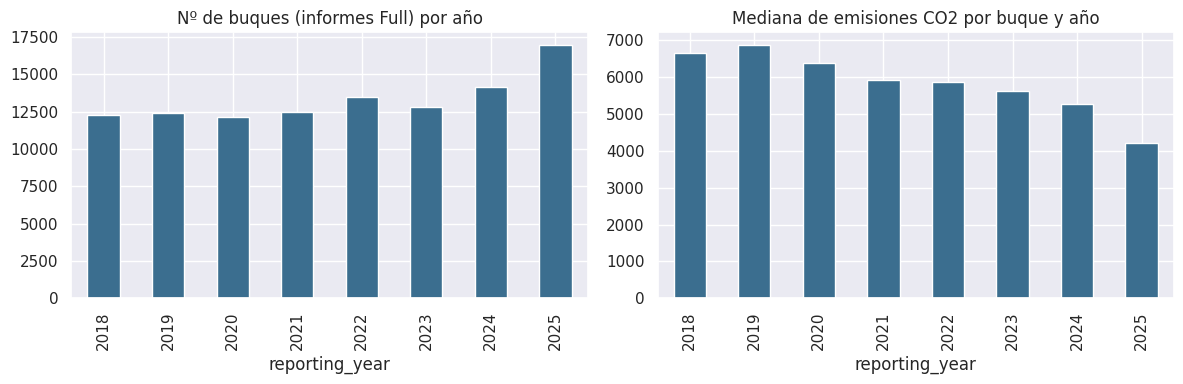

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datos.groupby("reporting_year").size().plot(kind="bar", ax=axes[0], color="#3B6E8F")
axes[0].set_title("Nº de buques (informes Full) por año")
datos.groupby("reporting_year")["total_co2_emissions_m_tonnes"].median().plot(kind="bar", ax=axes[1], color="#3B6E8F")
axes[1].set_title("Mediana de emisiones CO2 por buque y año")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_evolucion_temporal.png", dpi=120)
plt.show()

El número de buques reportando crece con los años (más que la mediana de emisiones por buque, que
incluso baja ligeramente) — coherente con la ampliación del alcance de la normativa MRV/ETS
(Reglamento (UE) 2023/957), no con que cada buque individual contamine más. Esto es
relevante para el TFM: si se usa el año como variable, no confundir "más buques en el dataset" con
"más emisiones por buque".

## 11. Relación con el target

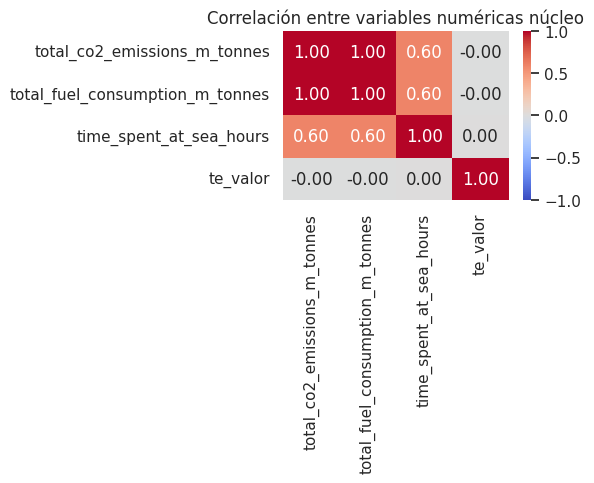

In [18]:
matriz_corr = datos[nucleo_num_ext].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas núcleo")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_correlacion_numericas.png", dpi=120)
plt.show()

{'ship_type': 0.3430529172985708,
 'ice_class': 0.08967744910540129,
 'te_metodo': 0.05493013850999335,
 'prop_missings': 0.027314048053788238}

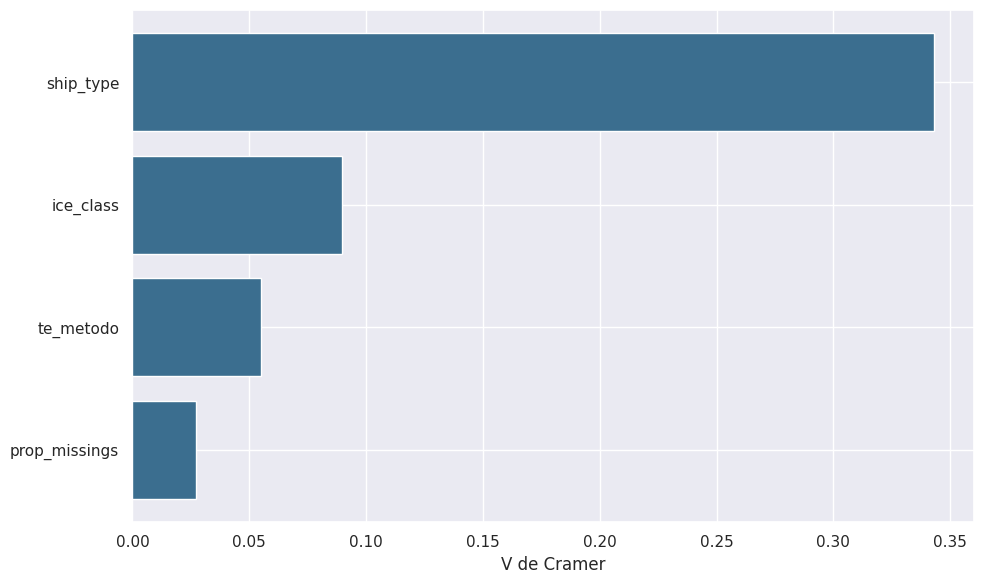

In [19]:
# Las medidas de asociación con el target se calculan sobre las filas con target conocido.
# Motivo: `Vcramer` convierte los NaN del target en una categoría propia ("missing"), y como las
# 180 filas sin CO2 fiable son exactamente las que tienen prop_missings alto, esa categoría sería
# predicha a la perfección por prop_missings — una circularidad que inflaría su V de Cramer de
# 0,027 a 0,570. Una asociación con el target no puede calcularse sobre filas sin target.
con_target = datos["total_co2_emissions_m_tonnes"].notna()

vars_categoricas_target = ["ship_type", "ice_class", "te_metodo", "prop_missings"]
vcramer_resultados = graficoVcramer(
    datos.loc[con_target, vars_categoricas_target],
    datos.loc[con_target, "total_co2_emissions_m_tonnes"],
)
plt.savefig(REPORTS_DIR / "02_vcramer_categoricas.png", dpi=120, bbox_inches="tight")
vcramer_resultados

### 11b. Tests de hipótesis explícitos

La V de Cramer de arriba ya usa por dentro un test chi-cuadrado de independencia
(`scipy.stats.chi2_contingency`), pero solo devuelve el estadístico normalizado, sin mostrar el
p-valor. Aquí se calcula de forma explícita para cada variable categórica frente al target
discretizado en quintiles (mismo criterio que usa `Vcramer` internamente), y se añade un ANOVA
(test F) de las emisiones de CO₂ por `ship_type` sobre el target en su escala original (sin
discretizar), para contrastar si al menos un tipo de buque tiene una media de emisiones distinta
de los demás.

In [20]:
# Chi-cuadrado de independencia, explícito, para cada categórica frente al target discretizado
# (mismo criterio que arriba: solo filas con target conocido)
datos_ct = datos.loc[con_target]
target_quintiles = pd.qcut(datos_ct["total_co2_emissions_m_tonnes"], 5, duplicates="drop")
resultados_chi2 = []
for var in vars_categoricas_target:
    tabla = pd.crosstab(datos_ct[var], target_quintiles)
    chi2, p, dof, _ = chi2_contingency(tabla)
    resultados_chi2.append({"variable": var, "chi2": round(chi2, 1), "p_valor": p, "gl": dof})
tabla_chi2 = pd.DataFrame(resultados_chi2).set_index("variable")
tabla_chi2

,chi2,p_valor,gl
variable,,,
ship_type,50143.8,0.000000e+00,64
ice_class,3426.6,0.000000e+00,44
te_metodo,1285.6,6.130839e-264,16
prop_missings,158.9,2.662274e-30,8


In [21]:
# ANOVA (test F): ¿difiere la media de CO2 entre tipos de buque?
grupos_ship_type = [g["total_co2_emissions_m_tonnes"].dropna().values for _, g in datos_ct.groupby("ship_type")]
f_stat, p_valor_anova = f_oneway(*grupos_ship_type)
print(f"ANOVA CO2 ~ ship_type: F={f_stat:.1f}, p-valor={p_valor_anova:.2e}")

ANOVA CO2 ~ ship_type: F=4156.5, p-valor=0.00e+00


In [22]:
# ¿Alguna transformación de time_spent_at_sea_hours mejora su correlación lineal con el target?
# Se calcula sobre las filas con target conocido (el CO2 ya no se imputa, ver sección 8).
con_target = datos["total_co2_emissions_m_tonnes"].notna()
nombre_transf, serie_transf = mejorTransfCorr(
    datos.loc[con_target, "time_spent_at_sea_hours"].reset_index(drop=True),
    datos.loc[con_target, "total_co2_emissions_m_tonnes"].reset_index(drop=True),
)
corr_original = datos["total_co2_emissions_m_tonnes"].corr(datos["time_spent_at_sea_hours"])
corr_transf = np.corrcoef(datos.loc[con_target, "total_co2_emissions_m_tonnes"], serie_transf)[0, 1]
print(f"Correlación original (time_spent_at_sea_hours): {corr_original:.3f}")
print(f"Mejor transformación encontrada: '{nombre_transf}', correlación: {corr_transf:.3f}")

Correlación original (time_spent_at_sea_hours): 0.599
Mejor transformación encontrada: 'x', correlación: 0.599


## 12. Conclusiones del EDA — qué factores influyen más en las emisiones

- **`total_fuel_consumption_m_tonnes` es, con diferencia, el predictor más fuerte** (correlación
  >0,95 con el CO₂ total) — coherente con que el CO₂ se define reglamentariamente como el
  combustible multiplicado por un factor fijo (ver notebook 01, validación física). Para el
  modelo, esto plantea una decisión de diseño importante: predecir el combustible (y de ahí derivar
  el CO₂) puede ser más informativo de cara a la interpretabilidad y al simulador de escenarios
  que predecir el CO₂ directamente sobre variables débilmente relacionadas.
- **`ship_type` tiene una asociación moderada** con las emisiones (V de Cramer 0,343) — buques
  como portacontenedores y graneleros grandes emiten órdenes de magnitud más que buques pequeños,
  visible en el boxplot de la Sección 9. El ANOVA de la Sección 11b lo confirma con un test de
  hipótesis explícito (F=4.156,5, p≈0): se rechaza con rotundidad que todos los tipos de buque
  tengan la misma emisión media.
- **`time_spent_at_sea_hours` tiene una correlación lineal moderada-alta con el CO₂ total (0,60)**
  — más fuerte de lo esperable a priori para una variable que, por sí sola, no dice nada del
  tamaño ni de la velocidad del buque. Tiene sentido: cuanto más tiempo navega un buque en el año,
  más combustible quema en total, con independencia de su tamaño. No es tan directa como el
  combustible (0,96, casi tautológica por la propia definición reglamentaria del CO₂), pero es la
  segunda variable núcleo más informativa y una candidata sólida como predictor independiente en
  la fase de modelización, no solo como interacción con el tipo de buque.
  **Nota metodológica**: esta correlación depende de haber fusionado, en el notebook 01,
  `time_spent_at_sea_hours` con su variante por cambio de rótulo del portal entre años — sin esa
  fusión (77% missing, imputado de forma aleatoria) la correlación aparente sería mucho más baja y
  engañosa.
- **`ice_class`** tiene una asociación débil-moderada (V de Cramer 0,090) — no aporta mucho como
  predictor aislado, aunque casi todos los buques no tienen clase de hielo asignada, y **`te_metodo`**
  (V de Cramer 0,055) todavía menos.
- **Significación estadística no es lo mismo que tamaño de efecto (Sección 11b)**: con 106.521 filas con target conocido,
  el test chi-cuadrado da p≈0 para las cuatro variables categóricas frente al target, incluida
  `prop_missings` (p=2,7·10⁻³⁰) — es decir, hay asociación real y no es casualidad del muestreo. Pero
  su V de Cramer es solo 0,027, la más baja de todas: la asociación es estadísticamente detectable
  pero demasiado débil para ser útil como predictor. Con un dataset tan grande, casi cualquier
  asociación por pequeña que sea acaba siendo "significativa" — por eso la V de Cramer (tamaño de
  efecto) es la que debe guiar la selección de variables para el modelo, no solo el p-valor.
- El **año** (`reporting_year`) no debe interpretarse como tendencia de emisiones por buque: el
  crecimiento del dataset a lo largo de los años refleja la ampliación del alcance regulatorio, no
  un cambio de comportamiento de cada buque individual (Sección 10).

Estas conclusiones son el punto de partida para el notebook 03 (feature engineering) y 04
(modelización): el conjunto de variables núcleo usado aquí es deliberadamente pequeño para el EDA,
pero en feature engineering se recuperarán variables adicionales (p.ej. ratios por distancia como
variables derivadas *del propio dataset histórico*, no como fuga de información del target actual).

- **Nota metodológica**: las medidas de asociación con el target
  (V de Cramer, chi-cuadrado, ANOVA) se calculan solo sobre las filas con CO₂ conocido. Al dejar de
  imputar la variable objetivo (sección 8), 180 filas salen del EDA sin target, y `Vcramer` las
  convertiría en una categoría propia ("missing") — que `prop_missings` predice a la perfección, por
  construcción. Sin ese filtro, la V de Cramer de `prop_missings` pasaría de 0,027 a 0,570 y aparecería
  como la variable más asociada al target, cuando lo único que mediría es su propia definición.
  Una decisión correcta aguas arriba (no imputar el target) puede activar un problema latente aguas
  abajo si no se revisa la cadena entera.

## 13. Guardado del dataset listo para EDA/modelización

In [23]:
out_path = PROCESSED_DIR / "mrv_eda.parquet"
datos.to_parquet(out_path, index=False)
print(f"Guardado: {out_path.relative_to(Path.cwd().parent)}  ({out_path.stat().st_size / 1e6:.1f} MB, {datos.shape[0]} filas x {datos.shape[1]} columnas)")
datos.dtypes

Guardado: data/processed/mrv_eda.parquet  (3.7 MB, 106701 filas x 13 columnas)


reporting_year                       int64
ship_imo_number                        str
ship_name                              str
company_name                           str
total_co2_emissions_m_tonnes       float64
total_fuel_consumption_m_tonnes    float64
time_spent_at_sea_hours            float64
ship_type                              str
ice_class                              str
technical_efficiency                   str
te_metodo                              str
te_valor                           float64
prop_missings                          str
dtype: object

## Siguientes pasos

- Notebook 03: feature engineering — recuperar variables adicionales del dataset consolidado
  original (no solo el núcleo usado aquí) y decidir el tratamiento de las subcategorías nuevas de
  `ship_type`.
- Notebook 04: modelización predictiva (ML clásico, varias técnicas comparadas).